<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/KAN_Heat_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
pip install pykan


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import torch
import kan
import csv
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from kan.utils import ex_round

SEED = 42
torch.random.manual_seed(SEED)
torch.set_default_dtype(torch.float64)


In [22]:
# ------ load data ---------
CSV_PATH = "/content/drive/MyDrive/Physics Informed ML/heat.csv"   # <-- adjust path if needed

# Standard-library CSV reader
with open(CSV_PATH, newline="") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

feature_names = ["qprime", "mdot", "Tin", "R", "L", "Cp", "k"]
output_name   = "T"

X_np = np.array([[float(r[c]) for c in feature_names] for r in rows])
y_np = np.array([float(r[output_name]) for r in rows])

print(f"Samples  : {X_np.shape[0]}")
print(f"T range  : {y_np.min():.1f} - {y_np.max():.1f} K")

# ---------------------

# ------ preprocess data ---------

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=SEED
)
y_train_np = y_train_np.reshape(-1, 1)  # size (N,) â†’ (N, 1) since I only have one output
y_test_np  = y_test_np.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = torch.tensor(scaler_X.fit_transform(X_train_np))
X_test  = torch.tensor(scaler_X.transform(X_test_np))
y_train = torch.tensor(scaler_y.fit_transform(y_train_np))
y_test  = torch.tensor(scaler_y.transform(y_test_np))

dataset = {
    "train_input": X_train,
    "train_label": y_train,
    "test_input" : X_test,
    "test_label" : y_test
}



Samples  : 1000
T range  : 1002.1 - 1671.9 K


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.51e-02 | test_loss: 2.46e-02 | reg: 7.49e+00 | : 100%|█| 100/100 [01:00<00:00,  1.66


saving model version 0.1


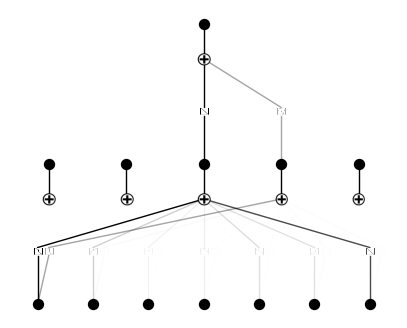

In [23]:
# ---------------------


# ----------- build initial KAN --------
# see Hyperparameters from Table 4 of the paper for some guidance (HEAT row):
# use a hidden width of 5.

model = kan.KAN(width=[7,5,1], grid=7, k=3, seed=SEED)

model.fit(dataset, opt='LBFGS', steps=100, lamb=1.899e-4,
          lamb_entropy=8.20921,lr=1.5, reg_metric="edge_forward_spline_u")
model.plot()
plt.show()
# ----------------------------




saving model version 0.2


| train_loss: 1.63e-02 | test_loss: 1.62e-02 | reg: 7.37e+00 | : 100%|█| 25/25 [00:07<00:00,  3.28it


saving model version 0.3


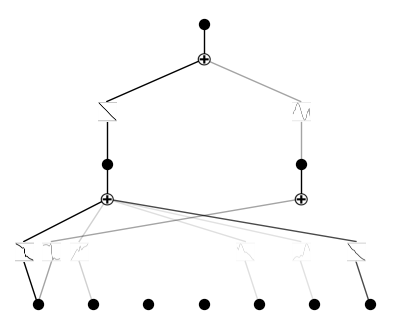

In [24]:
# --------- prune and retrain ----------

model = model.prune()
model.plot()

model.fit(dataset, opt='LBFGS', steps=25, lr=1);



In [ ]:
# --------------------------------------


# -------- convert splines to symbolic expressions ---------

# check spline predictions before symbolic conversion
with torch.no_grad():
    y_spline_s = model(X_test)  # (N, 1)
r2_spline = r2_score(y_test.numpy(), y_spline_s.numpy())
print(f"Spline KAN   RÂ² = {r2_spline:.4f}")
# r2 is invariant under linear transformation so don't need to unscale

# convert to symbolic, train some more, and check predictions again

model.auto_symbolic(weight_simple=0.1)

model.fit(dataset, opt='LBFGS', steps=50);
from kan.utils import ex_round
sym_expr = ex_round(model.symbolic_formula()[0][0],4)




Spline KAN   RÂ² = 0.9947
fixing (0,0,0) with tan, r2=0.7640631904285993, c=3
fixing (0,0,1) with sgn, r2=0.9389669092281686, c=3
fixing (0,1,0) with tan, r2=0.9778271906977779, c=3
fixing (0,1,1) with 0
fixing (0,2,0) with 0
fixing (0,2,1) with 0
fixing (0,3,0) with 0
fixing (0,3,1) with 0
fixing (0,4,0) with x, r2=0.9802241703390885, c=1
fixing (0,4,1) with 0
fixing (0,5,0) with tanh, r2=0.9823566087651605, c=3
fixing (0,5,1) with 0
fixing (0,6,0) with sin, r2=0.998689373325604, c=2
fixing (0,6,1) with 0
fixing (1,0,0) with sin, r2=0.9993723784074132, c=2
fixing (1,1,0) with gaussian, r2=0.9718672587433372, c=3
saving model version 0.4


| train_loss: 6.59e-02 | test_loss: 5.98e-02 | reg: 0.00e+00 | :  82%|▊| 41/50 [00:19<00:03,  2.27it

In [ ]:



print(f"\n    T_scaled = {sym_expr}\n")
print("Note: variables in this equation are min-max scaled to [0, 1].")

# now check r2 of the symbolic formula
with torch.no_grad():
    y_sym_s = model(X_test)  # (N, 1)
r2_symbolic = r2_score(y_test.numpy(), y_sym_s.numpy())
print(f"Symbolic KAN   RÂ² = {r2_symbolic:.4f}")


# ------- visualize -------

y_test_np   = scaler_y.inverse_transform(y_test.numpy())
y_spline_np = scaler_y.inverse_transform(y_spline_s.numpy())
y_sym_np    = scaler_y.inverse_transform(y_sym_s.numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Parity plot
ax = axes[0]
lo, hi = y_test_np.min() - 10, y_test_np.max() + 10
ax.scatter(y_test_np, y_spline_np, alpha=0.35, s=14,
           label=f"Spline   RÂ²={r2_spline:.3f}")
ax.scatter(y_test_np, y_sym_np,    alpha=0.35, s=14,
           label=f"Symbolic RÂ²={r2_symbolic:.3f}")
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("True T [K]"); ax.set_ylabel("Predicted T [K]")
ax.set_title("Parity plot"); ax.legend()

# Residual histogram
ax = axes[1]
residuals = y_sym_np - y_test_np
ax.hist(residuals, bins=40, edgecolor="white", linewidth=0.5, color="steelblue")
ax.axvline(0, color="k", linestyle="--", lw=1)
ax.set_xlabel("Residual  (Predicted - True)  [K]")
ax.set_ylabel("Count")
ax.set_title(f"Symbolic KAN residuals  (mean = {residuals.mean():.2f} K)")

plt.tight_layout()
plt.show()